# 5 - Neo-Riemannian Transformations

In [2]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [4]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia
from Importables import tonnetz_utils as t

In [5]:
metadata = g.load_metadata()

## Test: One piece

In [8]:
test = metadata[metadata['fnames'] == 'Final Thought - Kamasi Washington']
labels = g.load_labels(test)
labels.head() 

,mc,mn,quarterbeats,quarterbeats_all_endings,duration_qb,mc_onset,mn_onset,timesig,staff,voice,harmony_layer,label,regex_match,artist,workTitle,fnames,rel_paths,recording_year,time,ILS
0,1,1,0,0,116.0,0.0,0,2/2,1,1,3,Dm,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,1.0,"[D, F, A]"
1,30,30,116,116,8.0,0.0,0,2/2,1,1,3,E-,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,30.0,"[E-, G, B-]"
2,32,32,124,124,8.0,0.0,0,2/2,1,1,3,Dm,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,32.0,"[D, F, A]"
3,34,34,132,132,8.0,0.0,0,2/2,1,1,3,E-,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,34.0,"[E-, G, B-]"
4,36,36,140,140,8.0,0.0,0,2/2,1,1,3,F,NaN,Kamasi Washington,Tenor Sax solo by Kamasi Washington\non Final ...,Final Thought - Kamasi Washington,by_Seth_Bailin,2015.0,36.0,"[F, A, C]"


In [10]:
transformations, exceptions = t.transformation(labels)
transformations.value_counts(subset=['transformation']).reset_index(name='count')

,transformation,count
0,N/A,14
1,N,2
2,R,2


## All :)))))

In [68]:
labels = g.load_labels(metadata)
transformations, exceptions = t.transformation(labels) 

In [69]:
transformations.value_counts(subset=['transformation']).reset_index(name='count') 

,transformation,count
0,N/A,17800
1,N,3034
2,P,835
3,R,376
4,H,296
5,L,205
6,S,189


### Exceptions

In [73]:
exceptions = labels[labels['label'].isin(exceptions)].value_counts(subset=['label']).reset_index(name='count')
exceptions

,label,count
0,Cm69,134
1,F13no3,27
2,E13no3,27
3,E-13no3,15
4,D13sus4,13
5,A-9sus4,6
6,D-M7no5,6
7,N.C.,4
8,C6sus2,4
9,C7no5,4


### Group by year

In [90]:
transformations['year_bin'] = pd.cut(transformations['recording_year'], bins=bins, labels=bin_labels, right=False)
tot_transformations = transformations.groupby(by=['year_bin']).size().reset_index(name='count')['count']
transformation = transformations[transformations['transformation']== 'L']
transformations_year_grouped = transformation.groupby(by=['year_bin']).size().reset_index(name='count')

snum = transformations_year_grouped['count'] * 100 / tot_transformations
snum = np.array(snum)
snum



array([1.2257564 , 0.71651663, 0.29154519, 1.35655362])

N/A: snum: [75.9193173  76.29983465 86.27494954 76.75527039]
N: snum: [16.88130334 15.37754915  7.49046871 12.22731439]
H: snum: [1.05508146 0.80837773 1.12132765 1.86984418]
P: snum: [2.68425136 3.6376998  2.87059879 5.1695692 ]
R: snum: [1.27230411 2.22303877 1.23346042 1.9248396 ]
L: snum: [1.2257564  0.71651663 0.29154519 1.35655362]
S: snum: [0.96198604 0.93698328 0.7176497  0.69660862]


/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_40649/242477321.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_40649/242477321.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_40649/242477321.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/ccr2_55x757_kgq1rt_lyy6c0000gn/T/ipykernel_40649/242477321.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(x,rotation=45)
/var/folders/dw/

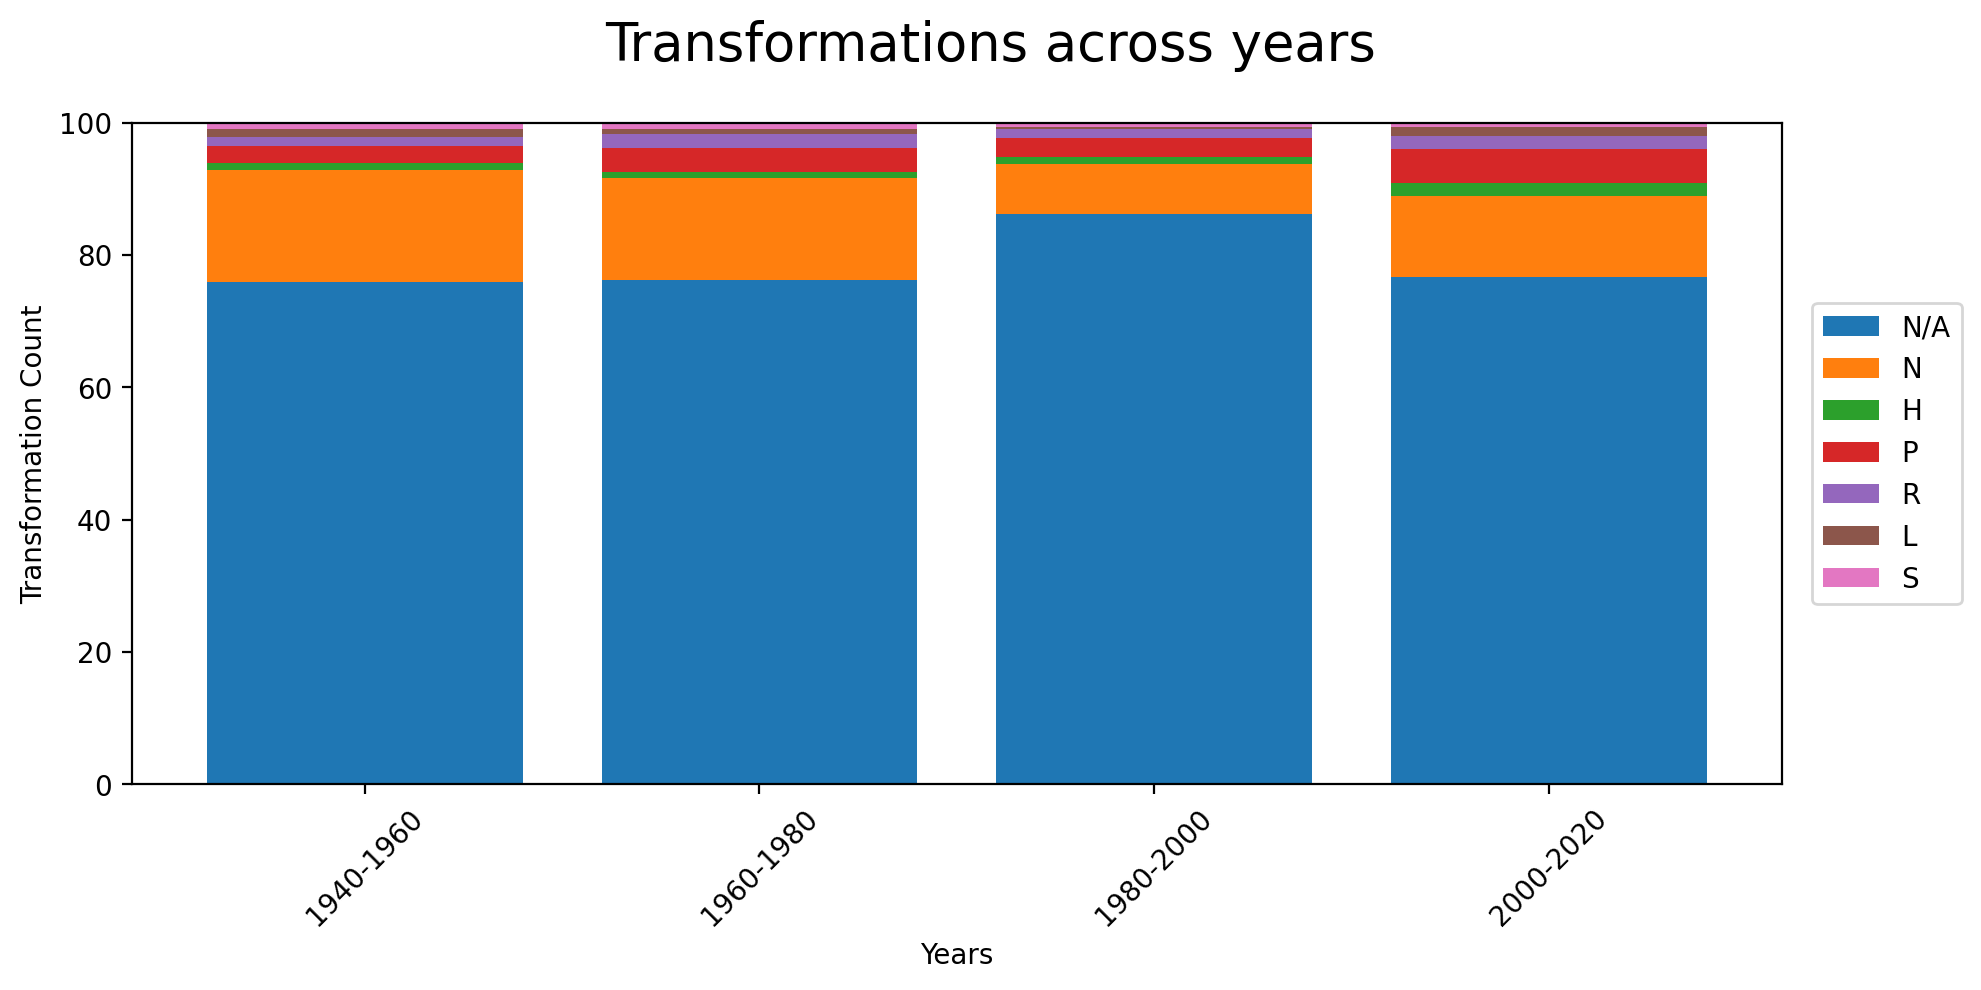

In [113]:
bins = [1940, 1960, 1980, 2000, 2020]
bin_labels = ['1940-1960', '1960-1980', '1980-2000', '2000-2020']

transformations['year_bin'] = pd.cut(transformations['recording_year'], bins=bins, labels=bin_labels, right=False)
tot_transformations = transformations.groupby(by=['year_bin']).size().reset_index(name='count')['count']

num_bins = len(bin_labels)
x = bin_labels

fig, ax = plt.subplots(figsize=(10, 5))
current_itn = np.zeros(len(bin_labels))
for t in transformations['transformation'].unique():
    transformation = transformations[transformations['transformation']== t]
    transformations_year_grouped = transformation.groupby(by=['year_bin']).size().reset_index(name='count')
    
    y = transformations_year_grouped['count'] * 100 / tot_transformations
    y = np.array(y)
    print(f"{t}: snum: {y}")

    ax.bar(x, y, bottom = current_itn, label=t)

    current_itn = current_itn + y

    ax.set_xlabel('Years')
    ax.set_ylabel('Transformation Count')
    ax.set_xticklabels(x,rotation=45)
    ax.set_ylim(0, 100)  # or whatever your consistent max value is
    ax.set_yticks(np.arange(0, 120, step=20))

plt.suptitle('Neo-Riemannian Transformations Frequencies', fontsize=19)
plt.legend(bbox_to_anchor=(1.01,0.5), loc='center left')
plt.tight_layout()
#plt.savefig(f"../Results/NotesPerChordMajor")
plt.show()